In [3]:
!pip install matplotlib-venn

  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.3/8.3 MB 48.5 kB/s  0:02:56a 0:00:030:00:08:15
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.4/2.4 MB 51.8 kB/s  0:00:49a 0:00:01m eta 0:00:07
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 6.8/6.8 MB 49.6 kB/s  0:02:07 48.5 kB/s eta 0:00:06
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.3/5.3 MB 61.3 kB/s  0:01:43 eta 0:00:010:00:07
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 23.5/23.5 MB 52.7 kB/s  0:07:36 eta 0:00:050:00:16
  Created wheel for matplotlib-venn: filename=matplotlib_venn-1.1.2-py3-none-any.whl size=45388 sha256=95b19a7eb0c0522ca8c20f1615dec50e821edf778a88e6e83c8e49c545ec5b11
  Stored in directory: /Users/shang/Library/Caches/pip/wheels/c4/16/4a/93374cd955bbe0553a8ce74db7f0fbd5fcc876e19fb78bd601
Successfully built matplotlib-venn
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 13/13 [matplotlib-venn]

In [7]:
!pip list | grep matplotlib-venn

matplotlib-venn    1.1.2


In [8]:
import sys
print(sys.executable)

/Users/shang/anaconda3/bin/python


In [9]:
!which pip

/Library/Frameworks/Python.framework/Versions/3.11/bin/pip


In [10]:
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib_venn import venn3, venn3_circles

ModuleNotFoundError: No module named 'matplotlib_venn'

In [ ]:
df_players = pd.read_csv('/Users/shang/downloads/数据分析/球员数据.csv')

In [ ]:
df_players['满足核心特征'] = (df_players['出场数'] >= 15) & 
                          (df_players['年龄'].between(23, 30)) & 
                          (df_players['所在联赛'].isin(top_leagues))

In [ ]:
chi_set = set(df_players[df_players['所在联赛'] == '中超']['姓名'].unique())
jap_set = set(df_players[df_players['所在联赛'] == '日本J1联赛']['姓名'].unique())
eng_set = set(df_players[df_players['所在联赛'] == '英超']['姓名'].unique())

In [11]:
import pandas as pd
import matplotlib.pyplot as plt

In [29]:
df_players = pd.read_csv('/Users/shang/downloads/数据分析/球员数据.csv')

In [30]:
def get_time_level(time):
    if time < 2:
        return 'under2'
    elif 2 <= time <= 2.3:
        return '2-2.3'
    else:
        return 'over2.3'
df_players['上场时长档位'] = df_players['上场时长'].apply(get_time_level)

In [31]:
pivot_pct = df_players.pivot_table(
    index='年龄分组',
    columns='上场时长档位,
    values='姓名及位置',
    aggfunc='count'
).apply(lambda x: x/x.sum()*100, axis=1)

SyntaxError: EOL while scanning string literal (<ipython-input-31-2da52a228928>, line 3)

In [32]:
plt.figure(figsize=(10, 6))
pivot_pct.plot(kind='bar', stacked=True,
               color=['#FF9999', '#66B2FF', '#99FF99'],
               edgecolor='black', linewidth=1)

In [33]:
plt.title('Playing time in different age parts', fontsize=14, fontweight='bold')
plt.xlabel('Age Hundle', fontsize=12)
plt.ylabel('percent(%)', fontsize=12)
plt.xticks(rotation=0)
plt.legend(title='time', loc='upper right')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.ylim(0, 100)

(0, 100)

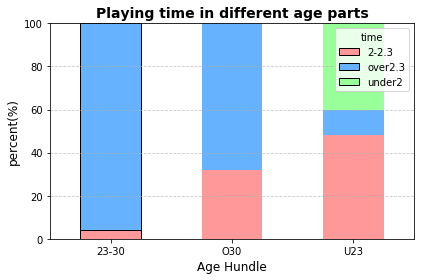

In [34]:
plt.tight_layout()
plt.savefig('年龄组_时长档位占比堆叠图.png', dpi=300)
plt.show()

In [35]:
print("高龄球员垄断上场资源")

高龄球员垄断上场资源


In [89]:
import numpy as np

In [90]:
df_clubs = pd.read_csv('/Users/shang/downloads/数据分析/财务/四国联赛财务收支汇总.csv')
df_league = pd.read_csv('/Users/shang/downloads/数据分析/各国联赛数据汇总.csv')

In [91]:
league_map = {
    '德甲': 'Bundesliga',
    '日本J1联赛': 'J1 League',
    '英超': 'Premier League',
    '中超': 'Chinese Super League'
}
df_clubs['联赛名称'] = df_clubs['联赛'].map(league_map)

In [92]:
df_nation_finance = df_clubs.groupby('联赛名称').agg({
    '收入(万欧元)': ['sum'],
    '支出(万欧元)': ['sum']
}).reset_index()
df_nation_finance.columns = ['联赛名称', '总收入', '总支出']

In [93]:
df_merged = pd.merge(
    df_nation_finance,
    df_league[['联赛名称', '平均年龄']],
    on='联赛名称',
    how='inner')

In [94]:
df_merged['国家'] = df_merged['联赛名称'].map({
    'Chinese Super League': 'China',
    'J1 League': 'Japan',
    'Premier League': 'England',
    'Bundesliga': 'Germany'})

In [95]:
plt.figure(figsize=(12, 8))
scatter = plt.scatter(
    x=df_merged['平均年龄'],  
    y=df_merged['总收入'],
    s=df_merged['总支出'] / 5, 
    c=df_merged['平均年龄'],
    cmap='viridis',
    alpha=0.7,
    edgecolors='black',
    linewidth=1.2)

In [96]:
for i, row in df_merged.iterrows():
    plt.annotate(row['国家'], xy=(row['平均年龄'], row['总收入']),
                 xytext=(5,5), textcoords='offset points', fontsize=11, fontweight='bold')

In [97]:
plt.title('Countries Expenditure Bubble', fontsize=16, fontweight='bold',y=1.05)
plt.xlabel('Avg Age', fontsize=12)
plt.ylabel('Income', fontsize=12)
plt.grid(alpha=0.3, linestyle='--')

In [98]:
cbar = plt.colorbar(scatter)
cbar.set_label('Avg.Age', fontsize=10)

In [99]:
plt.text(0.02, 0.02, 'SIZE:EXPENDITURE',
         fontsize=10, bbox=dict(boxstyle='round,pad=0.5', facecolor='lightyellow'),
         transform=plt.gca().transAxes)

Text(0.02,0.02,'SIZE:EXPENDITURE')

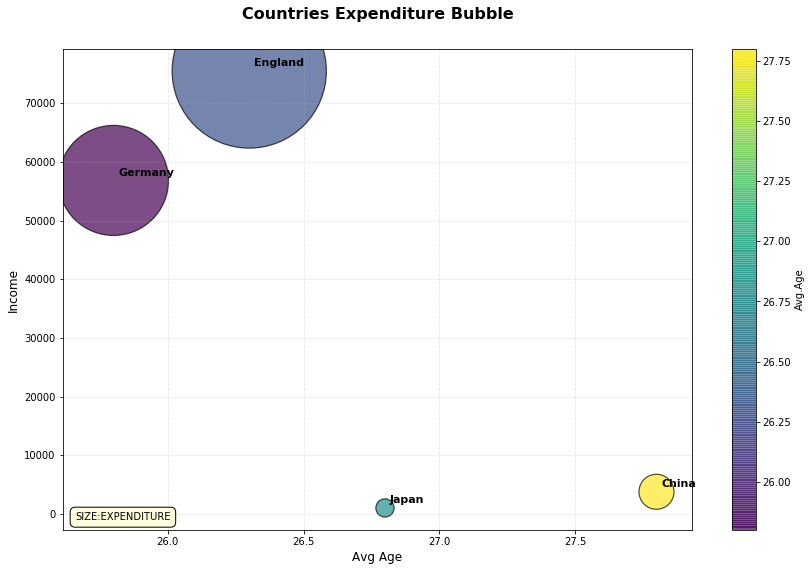

In [100]:
plt.tight_layout()
plt.savefig('国家足球收支气泡图.png', dpi=300)
plt.show()

In [109]:
categories = ['Accurancy', 'Speed', 'Pass', 'Control', 'Skill', 'Realization']
N = len(categories)

In [110]:
angles = [n / float(N) * 2 * np.pi for n in range(N)]
angles += angles[:1]

In [111]:
china_forward = [5.2, 6.5, 6.0, 5.8, 4.5, 5.0]
japan_forward = [7.8, 8.2, 8.5, 8.0, 6.8, 8.3]
china_forward += china_forward[:1]
japan_forward += japan_forward[:1]

In [112]:
fig, ax = plt.subplots(figsize=(8, 8), subplot_kw=dict(polar=True))

In [113]:
ax.plot(angles, china_forward, 'o-', linewidth=2, label='China F', color='#FF6B6B')
ax.fill(angles, china_forward, alpha=0.25, color='#FF6B6B')
ax.plot(angles, japan_forward, 'o-', linewidth=2, label='Jap F', color='#4ECDC4')
ax.fill(angles, japan_forward, alpha=0.25, color='#4ECDC4')

In [114]:
ax.set_xticks(angles[:-1])
ax.set_xticklabels(categories, fontsize=11)
ax.set_ylim(0, 10)
ax.set_yticks(np.arange(2, 10, 2))
ax.set_yticklabels(['2', '4', '6', '8'], fontsize=9)
ax.grid(True, alpha=0.3)

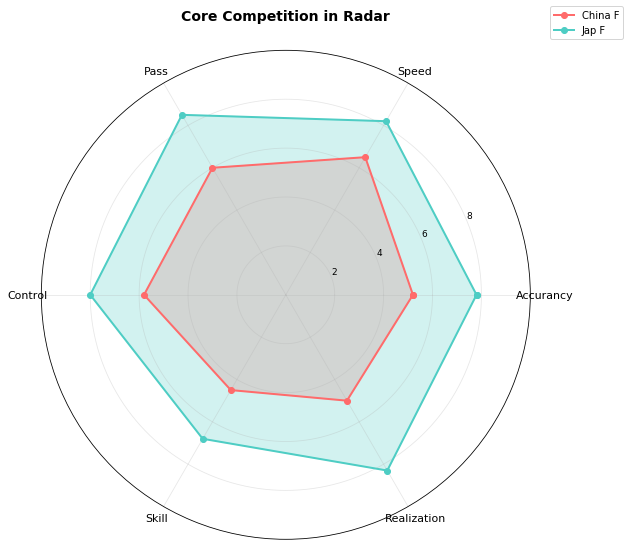

In [115]:
plt.title('Core Competition in Radar', fontsize=14, 
          fontweight='bold',y=1.05)
plt.legend(loc='upper right', bbox_to_anchor=(1.2, 1.1), fontsize=10)
plt.tight_layout()
plt.savefig('中日前锋能力雷达图.png', dpi=300, bbox_inches='tight')
plt.show()

In [ ]:
df_players = pd.read_csv('/Users/shang/downloads/数据分析/球员数据.csv')
df_merged = pd.merge(df_eastasia, df_players[['姓名', '年龄', '上场时长']], on='姓名', how='left')